# 1.1 Statistical Science: Description and Inference

This notebook is the runnable companion of statistics studies:

It uses simulated data so it runs in Google Colab without downloads, credentials, or private data. The example is original and designed to show the difference between describing a sample and making an inference about a population.

## Learning objectives

By the end of the notebook, I should be able to:

1. identify a population, sample, parameter, and statistic;
2. write separate descriptive and inferential conclusions;
3. visualize sampling variability through repeated sampling;
4. explain why larger samples usually produce more stable estimates; and
5. connect sampling uncertainty to the evaluation of an AI model.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 500
rng = np.random.default_rng(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 3)

print(f"Random seed: {SEED}")

Random seed: 500


## Population and research question

Imagine a university wants to understand weekly study time among its students.

- **Population:** all currently enrolled students at the university.
- **Parameter:** the true population mean of weekly study hours.
- **Sample:** the students selected for the study.
- **Statistic:** the sample mean calculated from the selected students.

Because this is a simulation, we can see the full population parameter. In a real study, that value would normally be unknown.

In [9]:
population_size = 100_000

population = pd.DataFrame({
    "student_id": np.arange(1, population_size + 1),
    "age": np.clip(rng.normal(25, 7, population_size).round(), 18, 65).astype(int),
    "weekly_study_hours": np.clip(
        rng.gamma(shape=4.0, scale=2.5, size=population_size), 0, 40
    ),
    "uses_ai_study_tool": rng.binomial(1, 0.46, population_size),
})

population.head()

,student_id,age,weekly_study_hours,uses_ai_study_tool
0,1,30,8.071,1
1,2,19,24.483,0
2,3,23,3.638,1
3,4,29,15.705,0
4,5,39,5.515,0


In [10]:
population_parameter = population["weekly_study_hours"].mean()
population_sd = population["weekly_study_hours"].std(ddof=0)

pd.Series({
    "population_size": len(population),
    "population_mean_hours": population_parameter,
    "population_sd_hours": population_sd,
})

population_size          100000.000
population_mean_hours        10.015
population_sd_hours           5.014
dtype: float64

## Draw one sample

We select a simple random sample of 200 students. The sample mean describes these 200 observations. We then use it as an estimate of the unknown population mean.

In [11]:
sample_size = 200
sample = population.sample(n=sample_size, random_state=SEED)

sample_statistic = sample["weekly_study_hours"].mean()
sample_sd = sample["weekly_study_hours"].std(ddof=1)
standard_error = sample_sd / np.sqrt(sample_size)
margin_of_error = 1.96 * standard_error
confidence_interval = (
    sample_statistic - margin_of_error,
    sample_statistic + margin_of_error,
)

pd.Series({
    "sample_size": sample_size,
    "sample_mean_hours": sample_statistic,
    "sample_sd_hours": sample_sd,
    "estimated_standard_error": standard_error,
    "95%_interval_lower": confidence_interval[0],
    "95%_interval_upper": confidence_interval[1],
})

sample_size                 200.000
sample_mean_hours             9.933
sample_sd_hours               4.462
estimated_standard_error      0.316
95%_interval_lower            9.314
95%_interval_upper           10.551
dtype: float64

### Two different conclusions

**Descriptive conclusion:** In this sample of 200 students, the average weekly study time is the calculated sample mean.

**Inferential conclusion:** If the sampling process is representative, the sample mean provides an estimate of the population mean. The interval communicates uncertainty from random sampling; it does not correct selection bias, measurement error, or nonresponse.

In [12]:
print(f"Sample mean: {sample_statistic:.2f} hours")
print(f"Population mean: {population_parameter:.2f} hours")
print(f"Sampling error in this sample: {sample_statistic - population_parameter:+.2f} hours")
print(
    "Approximate 95% interval: "
    f"[{confidence_interval[0]:.2f}, {confidence_interval[1]:.2f}] hours"
)

Sample mean: 9.93 hours
Population mean: 10.02 hours
Sampling error in this sample: -0.08 hours
Approximate 95% interval: [9.31, 10.55] hours


## Repeated sampling

A statistic changes from sample to sample. Repeating the sampling process lets us visualize that variability.

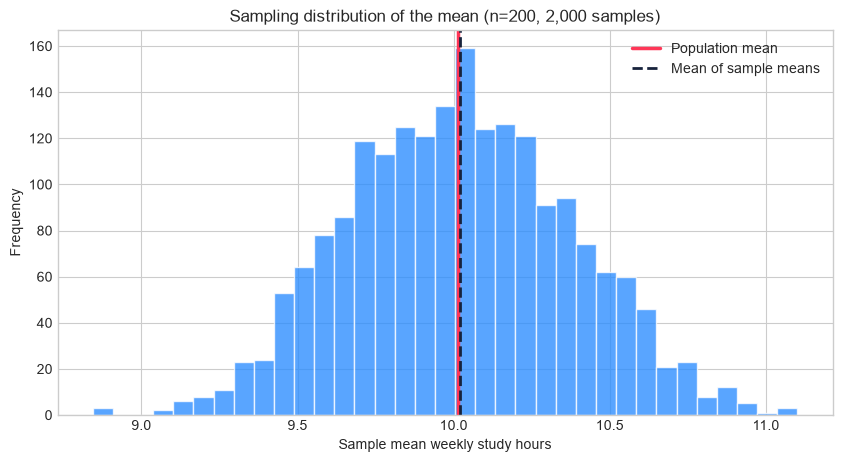

In [13]:
repetitions = 2_000
study_hours = population["weekly_study_hours"].to_numpy()

sample_means = np.array([
    rng.choice(study_hours, size=sample_size, replace=False).mean()
    for _ in range(repetitions)
])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sample_means, bins=35, color="#2a8cff", alpha=0.78, edgecolor="white")
ax.axvline(population_parameter, color="#ff3657", linewidth=2.5, label="Population mean")
ax.axvline(sample_means.mean(), color="#17233c", linestyle="--", linewidth=2, label="Mean of sample means")
ax.set(
    title=f"Sampling distribution of the mean (n={sample_size}, {repetitions:,} samples)",
    xlabel="Sample mean weekly study hours",
    ylabel="Frequency",
)
ax.legend()
plt.show()

In [ ]:
pd.Series({
    "population_mean": population_parameter,
    "mean_of_sample_means": sample_means.mean(),
    "sd_of_sample_means": sample_means.std(ddof=1),
    "theoretical_standard_error": population_sd / np.sqrt(sample_size),
})

## How sample size changes precision

We repeat the experiment for several sample sizes. The target parameter stays the same, but the sampling distributions become narrower as the sample size increases.

In [14]:
sample_sizes = [25, 100, 400, 1_600]
precision_rows = []

for n in sample_sizes:
    means = np.array([
        rng.choice(study_hours, size=n, replace=False).mean()
        for _ in range(1_000)
    ])
    precision_rows.append({
        "sample_size": n,
        "mean_of_estimates": means.mean(),
        "observed_standard_error": means.std(ddof=1),
        "theoretical_standard_error": population_sd / np.sqrt(n),
    })

precision = pd.DataFrame(precision_rows)
precision

,sample_size,mean_of_estimates,observed_standard_error,theoretical_standard_error
0,25,10.003,0.972,1.003
1,100,10.010,0.489,0.501
2,400,10.030,0.247,0.251
3,1600,10.025,0.121,0.125


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    precision["sample_size"],
    precision["observed_standard_error"],
    marker="o",
    linewidth=2.5,
    color="#ff3657",
)
ax.set_xscale("log")
ax.set(
    title="Larger samples produce more stable mean estimates",
    xlabel="Sample size (log scale)",
    ylabel="Observed standard error",
)
plt.show()

## Connection to artificial intelligence

An AI model is trained and evaluated on samples but is expected to work on a wider deployment population. This creates the same separation:

| Statistical term | AI example |
| --- | --- |
| Population | All future cases where the model will be used |
| Sample | Training, validation, or test observations |
| Parameter | True deployment accuracy, error rate, or calibration |
| Statistic | Accuracy or another metric measured on the test sample |

A test score is not a permanent property of a model. It is a sample statistic with uncertainty. Larger evaluation samples reduce random variability, but they do not repair dataset shift, leakage, poor measurement, or an unrepresentative benchmark.

## Exercises

1. Change `sample_size` from 200 to 50. How does the sampling distribution change?
2. Replace simple random sampling with a biased sample that overrepresents students with high study hours. Does a larger biased sample approach the population mean?
3. Repeat the simulation for the proportion of students using an AI study tool. Identify the parameter and statistic.
4. Treat model accuracy as a sample statistic. Simulate evaluation sets of different sizes and compare their variability.
5. Write one descriptive conclusion and one inferential conclusion without overstating the evidence.

## Docusaurus summary

Copy the strongest figure and a short interpretation back into the matching note after completing the exercises. The written page should explain the concept; this notebook should provide the reproducible evidence.

**Key takeaway:** Descriptive statistics summarize the observations in hand. Statistical inference uses sample evidence to reason about a wider population while making uncertainty and study-design limitations visible.